## 1. Imports

In [10]:
%pip install --quiet -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from sklearn.preprocessing import LabelEncoder

## 2. Data Loading

This section loads all `.npz` files from a specified directory, extracts `spectro`, `audio`, and `labels` arrays, and concatenates them into unified datasets.

In [12]:
data_folder_path = './data'

all_spectro = []
all_audio = []
all_spec_flag = []
all_flicker = []
all_labels = []

npz_files = glob.glob(os.path.join(data_folder_path, '*.npz'))

if not npz_files:
    raise FileNotFoundError(f"No .npz files found in {data_folder_path}. Please upload your data.")

for file_path in npz_files:
    filename = os.path.basename(file_path)
    label_name = filename.split('_')[0] 
    
    with np.load(file_path) as data:
        spectro_data = data['spectro']
        audio_data = data['audio']
        spec_flag_data = data['spec_flag']
        flicker_data = data['flicker']
        
        all_spectro.append(spectro_data)
        all_audio.append(audio_data)
        all_spec_flag.append(spec_flag_data)
        all_flicker.append(flicker_data)
        all_labels.append(np.full(spectro_data.shape[0], label_name))

full_spectro_data = np.concatenate(all_spectro, axis=0)
full_audio_data = np.concatenate(all_audio, axis=0)
full_spec_flag = np.concatenate(all_spec_flag, axis=0)
full_flicker = np.concatenate(all_flicker, axis=0)
full_labels = np.concatenate(all_labels, axis=0)

print(f"Loaded {len(npz_files)} files.")
print(f"Full Spectro Data Shape: {full_spectro_data.shape}")
print(f"Full Audio Data Shape: {full_audio_data.shape}")
print(f"Full Spec Flags Shape: {full_spec_flag.shape}")
print(f"Full Flicker Data Shape: {full_flicker.shape}")
print(f"Full Labels Shape: {full_labels.shape}")

Loaded 2 files.
Full Spectro Data Shape: (6038, 10)
Full Audio Data Shape: (6038, 2034)
Full Spec Flags Shape: (6038,)
Full Flicker Data Shape: (6038,)
Full Labels Shape: (6038,)


In [13]:
y_original = full_labels

print("Data arrays ready for windowing pipeline.")

Data arrays ready for windowing pipeline.


## 3. Windowing

We'll define a function that takes `window_size` as an argument. For each window:

1.  **Spectro Features**: The median of the spectro features within the `window_size` packets will be calculated.
2.  **Audio Samples**: The raw audio samples from all `window_size` packets will be concatenated.
3.  **Label**: The label of the packets in the window will be used for the windowed entry (discarding mixed packets).

In [14]:
window_size = 3  # Must be >= 3 as you noted!

def create_windowed_dataset(X_spectro, X_audio, X_spec_flag, X_flicker, y_original, window_size):
    X_windowed = []
    y_windowed = []

    # Process chunks using non-overlapping windows
    for i in range(0, len(y_original) - window_size + 1, window_size):
        current_window_labels = y_original[i : i + window_size]

        # Check if all labels in the window match to prevent cross-contamination
        if np.all(current_window_labels == current_window_labels[0]):
            
            # 1. Slice windows for each stream
            spectro_window = X_spectro[i : i + window_size]
            audio_window = X_audio[i : i + window_size]
            spec_flag_window = X_spec_flag[i : i + window_size]
            flicker_window = X_flicker[i : i + window_size]

            # 2. Process Spectral Data with your conditional logic
            valid_indices = np.where(spec_flag_window == 1)[0]
            if len(valid_indices) > 0:
                # If multiple valid packets exist, average them
                processed_spectro = np.mean(spectro_window[valid_indices], axis=0)
            else:
                # Fallback: if no valid packet is found, use the first packet's values
                processed_spectro = spectro_window[0]

            # 3. Process Audio Data (Flatten/Concatenate all samples in window)
            concatenated_audio = audio_window.flatten()

            # 4. Process Flicker Data (Find the most frequent flicker type in this window)
            # (Using a single integer value as a valuable environment feature)
            vals, counts = np.unique(flicker_window, return_counts=True)
            window_flicker_feature = np.array([vals[np.argmax(counts)]])

            # 5. Fuse all processed features into a single array vector
            windowed_feature_vector = np.hstack((processed_spectro, concatenated_audio, window_flicker_feature))

            X_windowed.append(windowed_feature_vector)
            y_windowed.append(current_window_labels[0]) 

    return np.array(X_windowed), np.array(y_windowed)

print(f"Creating windowed dataset with window_size = {window_size}...\n")
X_windowed, y_windowed = create_windowed_dataset(
    full_spectro_data, 
    full_audio_data, 
    full_spec_flag, 
    full_flicker, 
    y_original, 
    window_size
)

print(f"Windowed X feature matrix shape: {X_windowed.shape}")
print(f"Windowed y label matrix shape: {y_windowed.shape}")

Creating windowed dataset with window_size = 3...

Windowed X feature matrix shape: (2011, 6113)
Windowed y label matrix shape: (2011,)


## 4. Prepare Windowed Data for Neural Network

Now, we'll split the newly windowed data into training and testing sets, and encode the labels for the neural network.

In [15]:
# Encode labels to numerical format for Keras
label_encoder_windowed = LabelEncoder()
y_windowed_encoded = label_encoder_windowed.fit_transform(y_windowed)

# Split the windowed data into training and testing sets
X_train_windowed, X_test_windowed, y_train_windowed_encoded, y_test_windowed_encoded = train_test_split(
    X_windowed, y_windowed_encoded, test_size=0.2, random_state=42, stratify=y_windowed_encoded
)

num_classes_windowed = len(label_encoder_windowed.classes_)
input_shape_windowed = (X_train_windowed.shape[1],)

print(f"Windowed X_train shape: {X_train_windowed.shape}")
print(f"Windowed y_train shape: {y_train_windowed_encoded.shape}\n")

print(f"Windowed X_test shape: {X_test_windowed.shape}")
print(f"Windowed y_test shape: {y_test_windowed_encoded.shape}\n")

print(f"New input shape for NN: {input_shape_windowed}")

Windowed X_train shape: (1608, 6113)
Windowed y_train shape: (1608,)

Windowed X_test shape: (403, 6113)
Windowed y_test shape: (403,)

New input shape for NN: (6113,)


## 5. Define and Train the Neural Network with Windowed Input

In [16]:
# Build the Sequential Model with the new input shape
model_windowed = keras.Sequential([
    keras.Input(shape=input_shape_windowed), # Use Input layer for input shape
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(num_classes_windowed, activation='softmax')
])

# Compile the model
model_windowed.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

model_windowed.summary()

# Train the model
print("\nTraining Neural Network with new windowed input...")
history_windowed = model_windowed.fit(X_train_windowed, y_train_windowed_encoded,
                                              epochs=50, batch_size=32, validation_split=0.2, verbose=1)
print("Training complete.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │       195,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,210 (766.45 KB)

 Trainable params: 196,210 (766.45 KB)

 Non-trainable params: 0 (0.00 B)


Training Neural Network with new windowed input...
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7519 - loss: 271.6556 - val_accuracy: 0.8385 - val_loss: 179.4416
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8523 - loss: 164.3204 - val_accuracy: 0.8385 - val_loss: 220.3887
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8709 - loss: 157.9982 - val_accuracy: 0.8727 - val_loss: 201.7088
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9129 - loss: 133.6883 - val_accuracy: 0.9006 - val_loss: 196.4886
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9005 - loss: 125.6327 - val_accuracy: 0.8230 - val_loss: 239.9394
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8935 - loss: 102.5890 - val_accuracy: 0.8354 - val_loss: 224.6720
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9269 - loss: 104.1173 - val_accuracy: 0.8602 - val_loss: 213.3958
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 

## 6. Evaluate the Windowed Neural Network

Test Loss (Windowed NN): 243.6748
Test Accuracy (Windowed NN): 0.9107
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Classification Report (Windowed Neural Network):
                 precision    recall  f1-score   support

OutsideSunShade       0.90      0.92      0.91       198
      StudyRoom       0.92      0.90      0.91       205

       accuracy                           0.91       403
      macro avg       0.91      0.91      0.91       403
   weighted avg       0.91      0.91      0.91       403



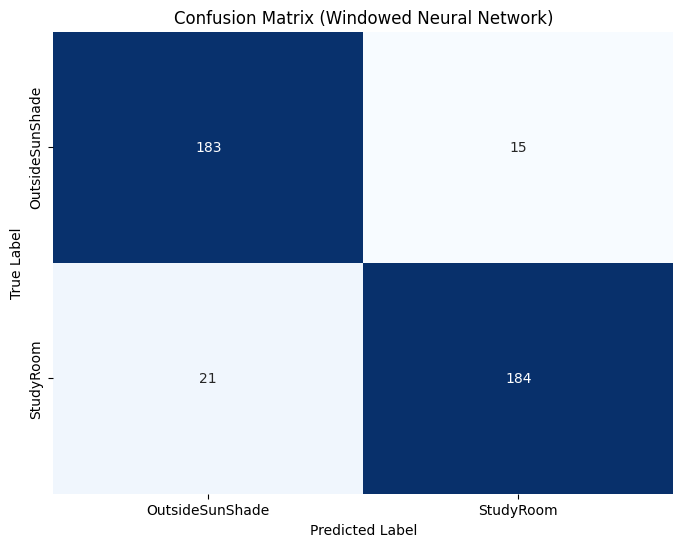

In [17]:
# Evaluate the model on the test set
loss_windowed, accuracy_windowed = model_windowed.evaluate(X_test_windowed, y_test_windowed_encoded, verbose=0)
print(f"Test Loss (Windowed NN): {loss_windowed:.4f}")
print(f"Test Accuracy (Windowed NN): {accuracy_windowed:.4f}")

# Make predictions
y_pred_proba_windowed = model_windowed.predict(X_test_windowed)
y_pred_nn_windowed = np.argmax(y_pred_proba_windowed, axis=1)

# Inverse transform labels for classification report
y_test_labels_windowed = label_encoder_windowed.inverse_transform(y_test_windowed_encoded)
y_pred_labels_windowed = label_encoder_windowed.inverse_transform(y_pred_nn_windowed)

# Print classification report
print("\nClassification Report (Windowed Neural Network):")
print(classification_report(y_test_labels_windowed, y_pred_labels_windowed))

# Plot confusion matrix
cm_nn_windowed = confusion_matrix(y_test_labels_windowed, y_pred_labels_windowed)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn_windowed, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=label_encoder_windowed.classes_, yticklabels=label_encoder_windowed.classes_)
plt.title('Confusion Matrix (Windowed Neural Network)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 7. Convert Windowed Model to TensorFlow Lite

In [18]:
# Define a representative dataset generator for full integer quantization
def representative_dataset_gen():
    # Use a small subset of the training data for calibration
    # It's important to use actual input data from your use case
    # for accurate quantization.
    for i in range(min(100, X_train_windowed.shape[0])):
        # The representative dataset must be in float32 as the original model expects float32 input.
        # This provides the range for the float32 to int8 quantization at the model input.
        yield [X_train_windowed[i:i+1].astype(np.float32)]

# Convert the Keras model to TensorFlow Lite format
converter_windowed = tf.lite.TFLiteConverter.from_keras_model(model_windowed)

# Enable optimizations for full integer quantization
converter_windowed.optimizations = [tf.lite.Optimize.DEFAULT]

# Specify the representative dataset
converter_windowed.representative_dataset = representative_dataset_gen

# Ensure only integer operations are used, and set input/output types as requested
converter_windowed.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# Set input to float32. The converter will add a Quantize op from float32 to int8.
converter_windowed.inference_input_type = tf.float32
converter_windowed.inference_output_type = tf.int8 # Set output to int8

tflite_model_windowed = converter_windowed.convert()

# Save the TFLite model to a file
tflite_file_path_windowed = 'nn_model_windowed_quantized.tflite' # Updated filename
with open(tflite_file_path_windowed, 'wb') as f:
    f.write(tflite_model_windowed)

print(f"Windowed Neural Network model successfully exported to {tflite_file_path_windowed} with full integer quantization (float32 I/O, int8 O/O) using a representative dataset.")
print("When performing inference, convert your int16 data to float32 before feeding it to this TFLite model.")
print("You can now import this .tflite file into STM32Cube.AI for further conversion and optimization for your STM32 microcontroller.")

INFO:tensorflow:Assets written to: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpg7naangj/assets


INFO:tensorflow:Assets written to: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpg7naangj/assets


Saved artifact at '/var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpg7naangj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6113), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  4912020176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4915512528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4915517520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4915516944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4915516560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4915516368: TensorSpec(shape=(), dtype=tf.resource, name=None)
Windowed Neural Network model successfully exported to nn_model_windowed_quantized.tflite with full integer quantization (float32 I/O, int8 O/O) using a representative dataset.
When performing inference, convert your int16 data to float32 before feeding it to this TFLite model.
You can 

/Users/mirko/Developer/SWDPProject/pipeline/venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1781711653.111784  323098 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1781711653.111797  323098 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1781711653.111888  323098 reader.cc:83] Reading SavedModel from: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpg7naangj
I0000 00:00:1781711653.112131  323098 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1781711653.112134  323098 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpg7naangj
I0000 00:00:1781711653.113996  323098 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1781711653.124766  323098 loader.cc:220] Running initialization op on SavedModel b